# Lab 02: Where Is the Star, and How Sure Are You Allowed to Be?

**ASTR 457, Fall 2026 — posted Thu Sep 10, due Wed Sep 16 by Noon (fork → PR, as always)**

*Why this lab: centroiding is how every position in every catalog you'll ever use was measured, and the Cramér–Rao bound is the professional's sanity check — the best precision any measurement can claim — that tells you instantly when an error bar in a paper (or from an AI) is too good to be true.*

Every one of you has your own dataset: `data/<your netid>.csv`, with a single column `x` —
the arrival positions, in pixels, of individual photons on a 1-D detector window spanning
$[0, 64]$ px. Most of the photons come from a star whose image on the detector is a Moffat
profile centered at $x_0$, with shape parameters $\beta = 2.5$ and $r_0 = 4$ px (both known
to you). The rest are **background**: a fraction $f_{\rm bg}$ of the photons, spread uniformly
across the window. I know the true $x_0$ and $f_{\rm bg}$ for your dataset. You don't, and you
can't look them up, and your classmates' values are different from yours. (So are their photon
counts — your Part 2 bound is yours alone.)

**How this is graded.** Not on whether your code runs — on whether your answers are *right*
and your uncertainties are *honest*. Part of your grade comes from how close your reported
$x_0$ and $f_{\rm bg}$ are to your truth **in units of your own reported uncertainty**. Report
tiny error bars you can't back up and you will lose points even if your central value is close.
Report huge error bars to be safe and you'll lose points too. Calibration is the skill.
And this week there is a floor under "huge": your reported $\sigma_{x_0}$ may not exceed
**3× the Cramér–Rao bound** you compute in Part 2. An error bar bigger than that is not
caution — it's an estimator you should have discarded.

**AI policy reminder.** Use whatever tools you like, including AI assistants — and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The naive estimator (15%)

Load your photon list and plot a histogram of the arrival positions (choose your binning
deliberately — you'll defend it). Then estimate the star's position the obvious way: the
**sample mean** of all the photon positions, with uncertainty $s/\sqrt{N}$ (the standard
error of the mean). Report $\hat{x}_0 \pm \sigma$.

Then answer, in a few sentences: is this estimator biased for *your* dataset, and why?
Which way does the bias pull, and what controls its size? (This estimator is *supposed* to
be biased. Understanding exactly how — and what the background has to do with it — is the
point.)

In [39]:
from scipy.optimize import minimize
from scipy.stats import norm
from scipy.special import gamma
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [35]:
data = pd.read_csv('../../labs/02/data/gracelh4.csv')

arrival_pos = data['x']
print(len(arrival_pos))

950


bins:  64


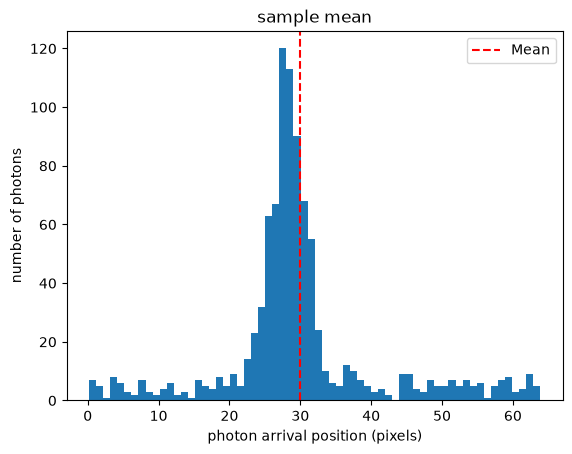

star's position:  29.98421907052632 +- 0.3596209157408047 px


In [27]:

bins = 64
print('bins: ', bins)
plt.hist(arrival_pos, bins=bins)
plt.axvline(sample_mean, color='red', linestyle='--', label='Mean')
plt.xlabel('photon arrival position (pixels)')
plt.ylabel('number of photons')
plt.title('sample mean')
plt.legend()
plt.show()

sample_mean = np.mean(arrival_pos)
N = len(arrival_pos)

s = np.std(arrival_pos, ddof = 1)
# ddof: delta degrees of freedom.

uncertainty = s / np.sqrt(N)

print("star's position: ", sample_mean, '+-', uncertainty, 'px')

**ANSWER (a few sentences):**
*your answer goes here*

In this naive estimator method, the dashed red line leans more to the right. Here, you can see that the red dashed line does not encompass the two highest bars on the histogram. The right side of the distribution, the tails, which are the background, are higher than the left side. That means that the background is pulling the entire estimation up. 


## Part 2: Estimators you can defend (40%)

Now do it properly. Estimate $x_0$ **three more ways** and compare:

1. **The median** of the photon positions. Robust, simple — but is it unbiased here, and
   what is its variance? (You may answer the variance question empirically in Part 3.)
2. **A sigma-clipped mean**: iteratively remove photons far from the current estimate,
   re-estimate, repeat until it converges. Be explicit about your clipping threshold and
   why you chose it.
3. **Maximum likelihood on the mixture model.** Each photon is background with probability
   $f_{\rm bg}$, or from the star otherwise, so the probability density for a single photon at
   position $x$ is

   $$p(x \mid x_0, f_{\rm bg}) \;=\; \frac{f_{\rm bg}}{64} \;+\; (1 - f_{\rm bg})\,
   \frac{\Gamma(\beta)}{r_0\sqrt{\pi}\,\Gamma(\beta - \tfrac{1}{2})}
   \left[1 + \left(\frac{x - x_0}{r_0}\right)^2\right]^{-\beta}$$

   with $\beta = 2.5$ and $r_0 = 4$ px. Maximize $\sum_i \ln p(x_i \mid x_0, f_{\rm bg})$ over
   both parameters (see Ivezić, Connolly, VanderPlas & Gray, §4.2, for the machinery — this
   is the same likelihood game with different symbols). Get uncertainties from the curvature
   of the log-likelihood at its peak (the observed information), and say so.

Then compute the **Cramér–Rao bound**: the smallest variance any unbiased estimator of $x_0$
can achieve given your $N$ photons. The per-photon Fisher information
$I(x_0) = \int \frac{1}{p}\left(\frac{\partial p}{\partial x_0}\right)^2 dx$ is yours to
evaluate — numerically over the window is fine — and the bound is
$\sigma_{x_0} \geq 1/\sqrt{N\,I}$. Treat both parameters as unknown: the honest bound comes
from inverting the $2\times 2$ Fisher matrix, not the $x_0$ term alone. How close does each
of your four estimators get?

(Two technicalities you may use without proof: photons landing outside the window were lost,
but for your $x_0$ the lost fraction is negligible — and checking that claim makes a fine
Part 3 sensitivity test. And for simulating: a 1-D Moffat with exponent $\beta$ is a
Student-$t$ distribution with $\nu = 2\beta - 1$ degrees of freedom, scaled by
$r_0/\sqrt{\nu}$.)

Commit to a **final answer** — one $x_0 \pm \sigma$ and $f_{\rm bg} \pm \sigma$ you'd put in
a paper — and justify the choice. State clearly how you estimated your uncertainties and why
you believe them. Remember the 3× rule from the header.

Median:  28.484428


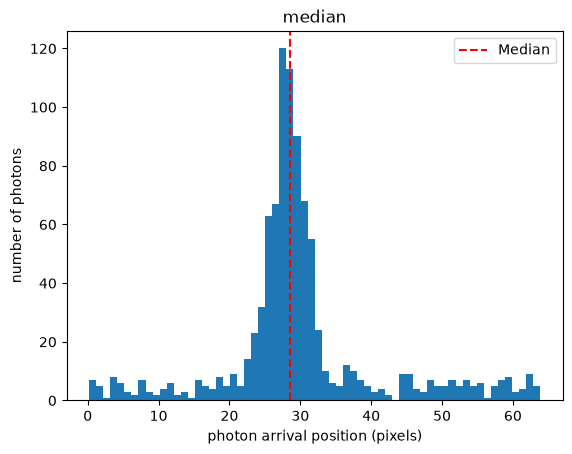

In [54]:
# a
median = np.median(arrival_pos)
std = np.std(median)
uncertainty = std / np.sqrt(N)
print('Median: ', median)

plt.hist(arrival_pos, bins=bins)
plt.axvline(median, color='red', linestyle='--', label='Median')
plt.xlabel('photon arrival position (pixels)')
plt.ylabel('number of photons')
plt.title('median')
plt.legend()
plt.show()

Sigma-clipped mean:  28.996595738327905  +- uncertainty 0.3214976882820152
Number clipped: 34


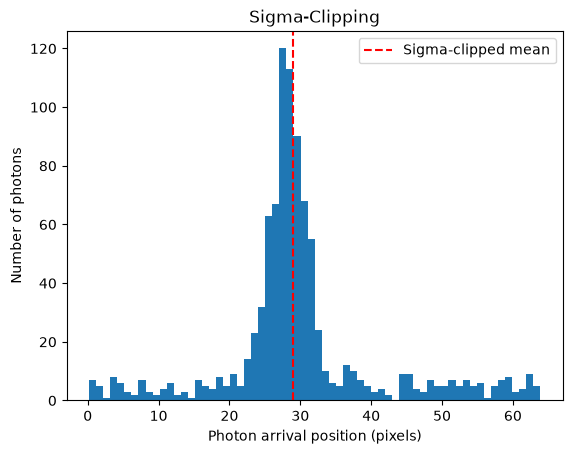

In [61]:
# b
def sigma_clip(x, k=3.0, max_iter = 10):
    mask = np.ones_like(x, dtype=bool)

    for _ in range(max_iter):
        mean = np.mean(x[mask])
        s = np.std(x[mask], ddof = 1)

        resid = (x - mean)/s
        new_mask = np.abs(resid) < k

        if np.array_equal(new_mask, mask):
            break
        mask = new_mask
    uncertainty = s / np.sqrt(mask.sum())
    return mean, mask, uncertainty


mean_clip, mask, uncertainty = sigma_clip(arrival_pos, k=3.0)



print("Sigma-clipped mean: ", mean_clip, " +- uncertainty", uncertainty)
print("Number clipped:", len(arrival_pos) - mask.sum())


plt.hist(arrival_pos, bins=bins)
plt.axvline(mean_clip, color='red', linestyle='--', label='Sigma-clipped mean')
plt.xlabel('Photon arrival position (pixels)')
plt.ylabel('Number of photons')
plt.title('Sigma-Clipping')
plt.legend()
plt.show()

In [55]:
# c
beta = 2.5
r0 = 4

def photon_pdf(x, x0, f_bg):
    # the first piece of that equation:
    background = f_bg / 64

    # the giant coefficent in front
    norm = gamma(beta) / (r0 * np.sqrt(np.pi) * gamma(beta - 0.5))

    star = norm * (1 + ((x - x0) / r0)**2) ** (-beta)

    #end equation
    return background + (1 - f_bg) * star


def neg_log_likelihood(params):
    x0, f_bg = params
    p = photon_pdf(arrival_pos, x0, f_bg)
    return -np.sum(np.log(p))

initial_guess = [29, 0.1]
result = minimize(neg_log_likelihood, initial_guess, bounds=[(0, 64), (0, 1)])

x0_fit, f_bg_fit = result.x

cov = np.asarray(result.hess_inv.todense())

x0_err = np.sqrt(cov[0, 0])
f_bg_err = np.sqrt(cov[1, 1])



In [56]:
x_grid = np.linspace(0, 64, 10000)
h = 1e-5
p = photon_pdf(x_grid, x0_fit, f_bg_fit)

dp_dx0 = (
    photon_pdf(x_grid, x0_fit + h, f_bg_fit)
    - photon_pdf(x_grid, x0_fit - h, f_bg_fit)
) / (2*h)

dp_df = (
    photon_pdf(x_grid, x0_fit, f_bg_fit + h)
    - photon_pdf(x_grid, x0_fit, f_bg_fit - h)
) / (2*h)

I_xx = np.trapezoid(dp_dx0**2 / p, x_grid)
I_ff = np.trapezoid(dp_df**2 / p, x_grid)
I_xf = np.trapezoid(dp_dx0 * dp_df / p, x_grid)

I_one = np.array([
    [I_xx, I_xf],
    [I_xf, I_ff]
])

I_total = N * I_one

C_crb = np.linalg.inv(I_total)


x0_crb = np.sqrt(C_crb[0, 0])

print("Cramer-Rao bound on x0:", x0_crb, "px")
print("x0 =", x0_fit, "+/-", x0_err, "px")
print("f_bg =", f_bg_fit, "+/-", f_bg_err)

Cramer-Rao bound on x0: 0.10090888431116037 px
x0 = 28.268989008723224 +/- 0.10318863253237412 px
f_bg = 0.3231686497518012 +/- 0.017850095378347808


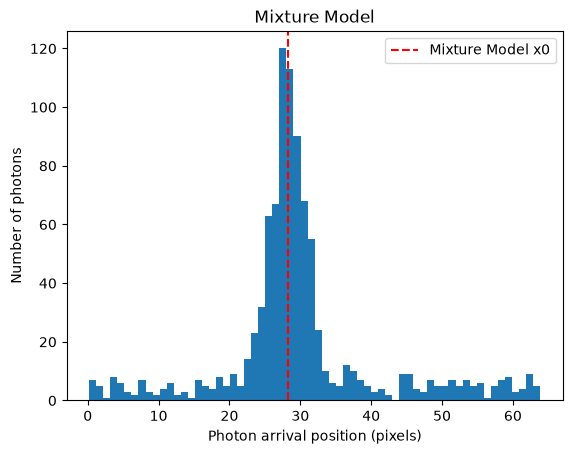

In [57]:
plt.hist(arrival_pos, bins=bins)
plt.axvline(x0_fit, color='red', linestyle='--', label='Mixture Model x0')
plt.xlabel('Photon arrival position (pixels)')
plt.ylabel('Number of photons')
plt.title('Mixture Model')
plt.legend()
plt.show()

**FINAL ANSWER:** $x_0 = $ 28.2689 $\pm$ 0.1009 px , $f_{\rm bg} = $ 0.3231 $\pm$ 0.01785 , Cramér–Rao bound $\sigma_{x_0}^{\rm CRB} = $ 0.1009 px

**Justification and uncertainty method (a short paragraph):**
*your answer goes here*

I chose the Mixture Model for my final answer. 

In both the Median and Sigma Clipping models, the x0 values that I plotted (the dashed red lines) still visually appeared to be pulled upwards by the background. Next, the error bar in the Sigma Clipping x0 value exceeded the 3x CRB requirement earlier in the lab, so I threw that estimator out. With the Median Model, while the estimator is not as biased as the mean, it still has the same issue--larger background values are still pulling upwards on the estimator. Since the tail on the right side is both larger and longer than the one on the left, those higher values still pull the red dashed line to the right, which is why I threw that estimator method out. 

The Mixture Model met the CRB requirement and visually appears to be unaffected by the higher values on the right. 


## Part 3: The verification plan — written first, then executed (35%)

This is the headline of this lab. **Before you run anything below, write the plan** (3a).
A verification plan you invent after seeing the results is a rationalization.

**3a. The plan.** List the checks you will run to decide whether to trust your Part 2
numbers. At minimum, address:

1. **Closure**: simulate a dataset with a truth *you* choose (the Student-$t$ fact from
   Part 2 makes this easy) and confirm your estimator recovers it.
2. **Bias and efficiency**: Monte Carlo all four estimators on many simulated datasets at
   plausible parameters. Plot their bias and their variance against the Cramér–Rao bound —
   this is *the* figure of this lab.
3. **Coverage**: across your simulations, do your 68% intervals contain the truth 68% of
   the time?
4. **Sensitivity**: what happens to your $\hat{x}_0$ if $\beta$ or $r_0$ are slightly wrong,
   or if the lost-photon fraction isn't negligible after all?

For **each** check, state *in advance* what failure would look like. A check that cannot
fail is not a check.

**3b. The execution.** Run the plan. Report what each check found — including anything that
failed or surprised you. A failed check honestly reported and diagnosed is worth more than
a wall of green checkmarks.

**VERIFICATION PLAN (write this before running 3b):**

*your plan goes here*

Closure:
I can simulate a dataset with the same known values (N, B, r0) as this dataset and a chosen x0 and f_bg. With that dataset, I can apply each method in this Lab to it to determine if the simulated positions are consistent with the current. If it were to fail, then one or more of the estimators must be off. 

Bias and Efficency: I will run Monte Carlo at plausible parameters and use each method in the lab for each simulated dataset. With that, I can measure the estimator's bias by calculating the simulated x0 minus the initial x0. I can also compare the variance to the CRB. Failure can look like a significant bias value or the variance differing significantly from the CRB. 


Coverage:
I will measure the confidence intervals for 68% to see if x0 falls in there across simulations. Failure would look like that spread varying across the simulations. 

Sensitivity:
I will slightly shift estimator values to see how many photons are left outside the window. If the shift in x0 is quite large, that would indicate failure. 


In [49]:
# Part 3b: execute the plan here


In [63]:
#closure
from scipy.stats import t

def simulate_data(N, x0_true, f_bg_true, beta=2.5, r0=4.0):
    rng = np.random.default_rng()
    nu = 2 * beta - 1
    scale = r0 / np.sqrt(nu)
    values = []

    while len(values) < N:
        if rng.random() < f_bg_true:
            x = rng.uniform(0, 64)
        else:
            x = x0_true + scale * rng.standard_t(nu)

        if 0 <= x <= 64:
            values.append(x)

    return np.array(values)


def mle_estimate(x):
    def nll(params):
        x0, f_bg = params
        p = photon_pdf(x, x0, f_bg)
        return -np.sum(np.log(p))

    result = minimize(
        nll,
        [28, 0.3],
        bounds=[(0, 64), (0, 1)]
    )

    return result.x[0]


x0_true = 28.0
f_bg_true = 0.32
N_sim = 950

sim = simulate_data(N_sim, x0_true, f_bg_true)

mean_sim = np.mean(sim)
median_sim = np.median(sim)
clip_sim, _, _ = sigma_clip(sim, k=3.0)
mle_sim = mle_estimate(sim)

print("True x0:", x0_true)
print("Mean:", mean_sim)
print("Median:", median_sim)
print("Sigma-clipped mean:", clip_sim)
print("MLE:", mle_sim)


True x0: 28.0
Mean: 29.365560511769395
Median: 28.250791924842822
Sigma-clipped mean: 28.40368781406397
MLE: 28.07753436100244


Mean bias: 1.307223276543149 variance: 0.11662374772732952
Median bias: 0.15619992788019965 variance: 0.013580551159592665
Sigma-clipped bias: 0.2727370059489432 variance: 0.3545399229998295
MLE bias: -0.004071607294262435 variance: 0.009688239892008434


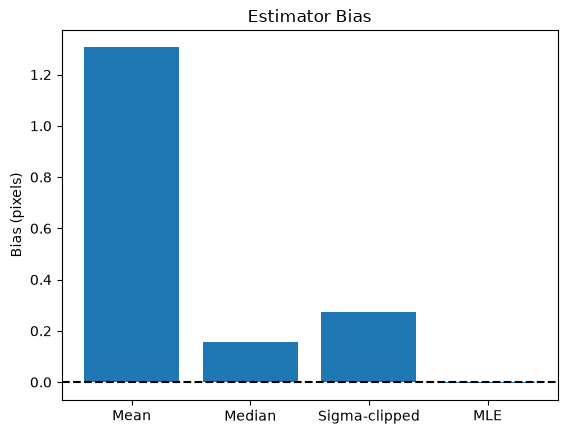

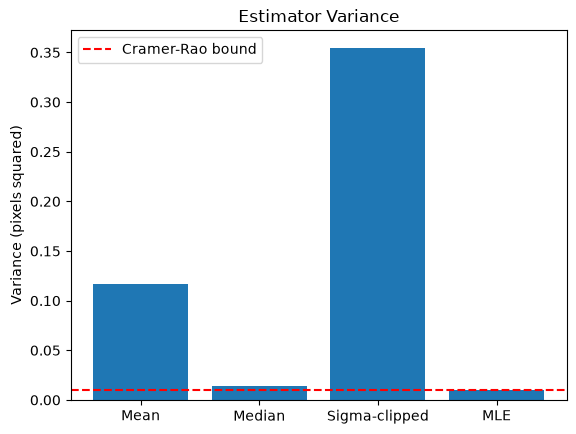

In [51]:
#bias and efficency
n_trials = 500

mean_estimates = []
median_estimates = []
clip_estimates = []
mle_estimates = []

for _ in range(n_trials):
    sim = simulate_data(N_sim, x0_true, f_bg_true)

    mean_estimates.append(np.mean(sim))
    median_estimates.append(np.median(sim))

    clip_value, _ = sigma_clip(sim, k=3.0)
    clip_estimates.append(clip_value)

    mle_estimates.append(mle_estimate(sim))

mean_estimates = np.array(mean_estimates)
median_estimates = np.array(median_estimates)
clip_estimates = np.array(clip_estimates)
mle_estimates = np.array(mle_estimates)

estimates = [
    mean_estimates,
    median_estimates,
    clip_estimates,
    mle_estimates
]

names = ['Mean', 'Median', 'Sigma-clipped', 'MLE']

biases = [
    np.mean(x - x0_true)
    for x in estimates
]

variances = [
    np.var(x, ddof=1)
    for x in estimates
]

for name, bias, variance in zip(names, biases, variances):
    print(name, "bias:", bias, "variance:", variance)

plt.bar(names, biases)
plt.axhline(0, color='black', linestyle='--')
plt.ylabel('Bias (pixels)')
plt.title('Estimator Bias')
plt.show()

plt.bar(names, variances)
plt.axhline(x0_crb**2, color='red', linestyle='--', label='Cramer-Rao bound')
plt.ylabel('Variance (pixels squared)')
plt.title('Estimator Variance')
plt.legend()
plt.show()

In [52]:
#coverage
mean_std = np.std(mean_estimates, ddof=1)
median_std = np.std(median_estimates, ddof=1)
clip_std = np.std(clip_estimates, ddof=1)
mle_std = np.std(mle_estimates, ddof=1)

stds = [
    mean_std,
    median_std,
    clip_std,
    mle_std
]

coverage = []

for est, std in zip(estimates, stds):
    inside = (
        (x0_true >= est - std) &
        (x0_true <= est + std)
    )

    coverage.append(np.mean(inside))

for name, value in zip(names, coverage):
    print(name, "68% coverage:", value)

Mean 68% coverage: 0.0
Median 68% coverage: 0.374
Sigma-clipped 68% coverage: 0.774
MLE 68% coverage: 0.68


In [53]:
#sensitivity

beta_values = [2.4, 2.5, 2.6]
r0_values = [3.8, 4.0, 4.2]

beta_results = []
r0_results = []

for beta_test in beta_values:
    sim = simulate_data(N_sim, x0_true, f_bg_true, beta=beta_test, r0=4.0)
    beta_results.append(mle_estimate(sim))

for r0_test in r0_values:
    sim = simulate_data(N_sim, x0_true, f_bg_true, beta=2.5, r0=r0_test)
    r0_results.append(mle_estimate(sim))

for beta_test, result in zip(beta_values, beta_results):
    print("beta =", beta_test, "x0 =", result, "shift =", result - x0_true)

for r0_test, result in zip(r0_values, r0_results):
    print("r0 =", r0_test, "x0 =", result, "shift =", result - x0_true)

nu = 2 * beta - 1
scale = r0 / np.sqrt(nu)

large_sample = x0_true + scale * np.random.standard_t(nu, size=1000000)

lost_fraction = np.mean(
    (large_sample < 0) |
    (large_sample > 64)
)

print("Lost photon fraction:", lost_fraction)

beta = 2.4 x0 = 28.04031869839589 shift = 0.04031869839588964
beta = 2.5 x0 = 27.848170666088087 shift = -0.15182933391191256
beta = 2.6 x0 = 28.005152261810697 shift = 0.005152261810696501
r0 = 3.8 x0 = 27.942651150829832 shift = -0.05734884917016814
r0 = 4.0 x0 = 27.98277832905561 shift = -0.017221670944390866
r0 = 4.2 x0 = 27.96734793081806 shift = -0.03265206918193897
Lost photon fraction: 0.000109


**WHAT THE CHECKS FOUND:**

*your report goes here*

Closure: This method recovered values that were similar to the values I found with the methods. The MLE's simulated truth value was quite similar to the Mixture Model, which supports the fact that it was the best model in Part 2. 

Bias & Efficency: The MLE had very small values here, which were close to the CRB bound. 

Coverage: This reported a value of exactly 0.68, indicating that all of the values were within 68%. 

Sensitivity: Shifts in beta and r0 did result in shifts, the largest of which were ~0.1. However, the fraction of lost photons was tiny, so for this lab it can be assumed to be negligible. 

## Part 4: AI-use appendix (10%)

**AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
is fine if true. (Your verification plan lives in Part 3 this week — it earned a
promotion. If an AI wrote any of it, that belongs here too.)

**AI-USE APPENDIX:**

Part 1:
I used ChatGPT.

I asked about plotting a histogram with matplot as I forgot what the tool was called. 

I asked about calculating the sample mean and error, specifically how to get the standard deviation. I forgot what tool in numpy that corresponds to. 

I asked about what binning does--I forgot what it is. 

I ran what I wrote through it and it caught an error--I used data in my plt.hist rather than arrival_pos. 

Asked ChatGPT what a background was in a detector. 
Part 2:
I used ChatGPT
A:
Asked if there was a median tool in numpy--yes. 

Asked if there was a way to plot a line representing mean/median--yes, used that boilerplate code that Chat gave me. 

I asked if there was anything I should add, added x and y labels & title. 

Asked if I should do the same calculation for the uncertainty as in part 1--got yes. 

Asked about weird runtime warning that I got, should not use ddof = 1 here. 

B:

Here I was asking about sigma clipping, and the differences between this problem and lab 1. I gave it my lab 1 code, and it gave me a version similar to my lab one code that was better for this task. I used that.

I asked for the boiler plate code to plot it. lop;

I asked for an additional code to get the uncertainty to report it. 

C:

I asked for the boilerplate code for the functions, as well as the uncertainty estimate.

I asked for the boiler-plate code for the CRB section. 

I asked more about the 3x Rule in the lab and cross checked with ChatGPT that I met that requirement.


3)
I asked for examples of verifying.

I requested the boiler plate code to perform the verifying plan that I wrote out.

I went through the results of the outputs from the code with ChatGPT to ensure that I understood them more. 


In general: 
I pasted all of the code I wrote to chat to ensure that I did not make m

I required help submitting this lab as well. 